In [3]:
import pandas as pd
import os

# === STEP 1: Set your folder path ===
folder_path = "/content/data"   # <-- CHANGE THIS

# === STEP 2: Get all CSV files ===
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# === STEP 3: Read and store DataFrames ===
df_list = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    print(f"Reading: {file}")

    df = pd.read_csv(file_path)
    df_list.append(df)

# === STEP 4: Combine all DataFrames ===
combined_df = pd.concat(df_list, ignore_index=True)

# === STEP 5: Save output ===
output_path = os.path.join(folder_path, "combined_output.csv")
combined_df.to_csv(output_path, index=False)

print(f"\n✅ Done! Combined file saved to: {output_path}")

Reading: 2002.csv
Reading: 2009.csv
Reading: 1999.csv
Reading: 2013.csv
Reading: 2019.csv
Reading: 2007.csv
Reading: 1994.csv
Reading: 2017.csv
Reading: 2021.csv
Reading: 2011.csv
Reading: 1993.csv
Reading: 2004.csv
Reading: 2003.csv
Reading: 1997.csv
Reading: 1995.csv
Reading: 2015.csv
Reading: 1998.csv
Reading: 2010.csv
Reading: 1992.csv
Reading: 2005.csv
Reading: 1996.csv
Reading: 2016.csv
Reading: 2020.csv
Reading: 2001.csv
Reading: 2022.csv
Reading: 2012.csv
Reading: 2018.csv
Reading: 2008.csv
Reading: 2000.csv
Reading: 2006.csv
Reading: 2014.csv

✅ Done! Combined file saved to: /content/data/combined_output.csv



Total Sedan Models Made Between 1992 and 2022:
     Origin  count
0  Domestic    948
1   Foreign   2061


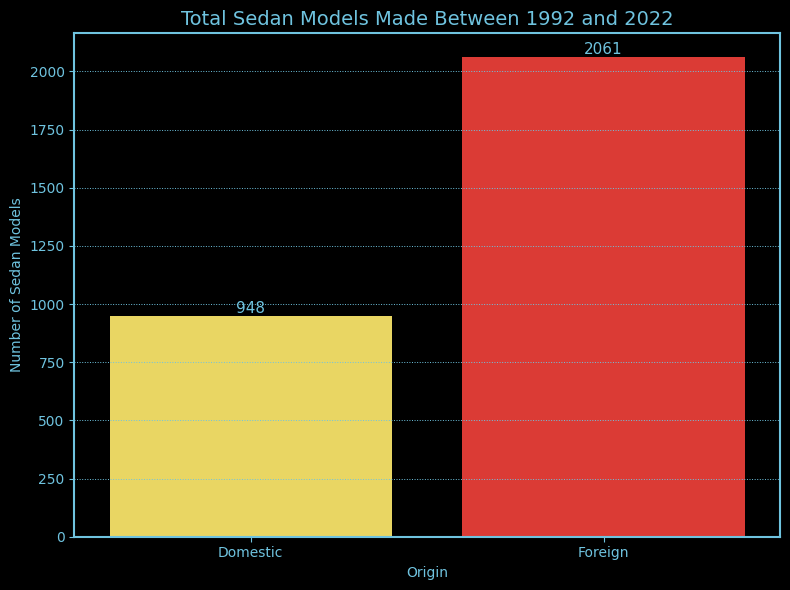

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------
# LOAD CSV
# -------------------------------------------

df = pd.read_csv("/content/data/combined_output.csv")

# -------------------------------------------
# AMERICAN / DOMESTIC MANUFACTURERS
# Add or remove names here if your dataset uses different spelling
# -------------------------------------------

american_makes = [
    "American Motors",
    "AM General",
    "Buick",
    "Cadillac",
    "Chevrolet",
    "Chrysler",
    "Dodge",
    "Eagle",
    "Ford",
    "GMC",
    "Hummer",
    "Jeep",
    "Lincoln",
    "Mercury",
    "Oldsmobile",
    "Plymouth",
    "Pontiac",
    "Ram",
    "Saturn",
    "Tesla"
]

# -------------------------------------------
# CLEAN DATA
# -------------------------------------------

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

df["make"] = df["make"].astype(str).str.strip()
df["body_styles"] = df["body_styles"].astype(str).str.strip()

# Keep only years 1992–2022
df = df[(df["year"] >= 1992) & (df["year"] <= 2022)]

# Mark Domestic vs Foreign
df["Origin"] = df["make"].apply(
    lambda x: "Domestic" if x in american_makes else "Foreign"
)

# Keep only sedans
sedans = df[df["body_styles"].str.contains("Sedan", case=False, na=False)].copy()

# -------------------------------------------
# COUNT SEDANS BY YEAR AND ORIGIN
# -------------------------------------------

sedan_counts = (
    sedans
    .groupby(["year", "Origin"])
    .size()
    .reset_index(name="count")
)

# -------------------------------------------
# TOTAL FOREIGN VS DOMESTIC SEDANS
# -------------------------------------------

sedan_totals = (
    sedan_counts
    .groupby("Origin")["count"]
    .sum()
    .reset_index()
)

print("\nTotal Sedan Models Made Between 1992 and 2022:")
print(sedan_totals)

domestic_total = sedan_totals.loc[
    sedan_totals["Origin"] == "Domestic", "count"
].sum()

foreign_total = sedan_totals.loc[
    sedan_totals["Origin"] == "Foreign", "count"
].sum()

# -------------------------------------------
# BAR CHART - TOTAL DOMESTIC VS FOREIGN SEDANS
# -------------------------------------------

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=sedan_totals,
    x="Origin",
    y="count",
    hue="Origin",
    palette={
        "Domestic": "#FFE64D",
        "Foreign": "#F72119"
    },
    legend=False
)

plt.title("Total Sedan Models Made Between 1992 and 2022", color="#6FC3DF", fontsize=14)
plt.xlabel("Origin", color="#6FC3DF")
plt.ylabel("Number of Sedan Models", color="#6FC3DF")

ax.set_facecolor("black")
plt.gcf().set_facecolor("black")

ax.grid(True, axis="y", color="#6FC3DF", linestyle=":", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_color("#6FC3DF")
    spine.set_linewidth(1.5)

ax.tick_params(axis="x", colors="#6FC3DF")
ax.tick_params(axis="y", colors="#6FC3DF")

for container in ax.containers:
    ax.bar_label(container, color="#6FC3DF", fontsize=11)

plt.tight_layout()
plt.show()